# Reto: Segundo Avance
## Spaceship Titanic

### Inteligencia Artificial Avanzada para la Ciencia de Datos

---

**Integrantes**

- Ana Paula Moreno
- David Tinoco Romero
- Emilio Páez de la Mora
- Alejandro Vázquez
- Emilio Torres

---

### Tecnológico de Monterrey

---

## Objetivo del notebook

Este notebook documenta el segundo avance del reto **Spaceship Titanic**: a partir del dataset ya preprocesado en el primer avance, se define un criterio de evaluación (métricas y baseline), se entrenan y comparan modelos de distinta familia (Regresión Logística y Random Forest), se elige el mejor modelo con evidencia de varias métricas, y cada integrante del equipo explora de forma independiente un hiperparámetro distinto sobre el modelo elegido. Finalmente se cierra con una tabla resumen de todo lo probado y las conclusiones del equipo.

El notebook está organizado en las siguientes secciones:

1. Carga de Datos Preprocesados
2. Selección de Métricas
3. Entrenamiento de Modelos
4. Comparativa de Modelos
5. Componente Individual: Exploración de Hiperparámetros
6. Verificación y Cierre

**Nota sobre correcciones respecto al primer avance:** en la Sección 1 se documentan y corrigen los errores de preparación detectados al intentar arrancar este segundo avance (falta de persistencia del dataset procesado a disco); no se modifica directamente el notebook del primer avance para no perder la trazabilidad de lo entregado en esa fase.

# 1. Carga de Datos Preprocesados

En el primer avance detectamos que el dataset limpio y transformado (`df_prep`)
nunca se guardó en disco: solo existía en memoria dentro del notebook anterior.
Esto es un error de preparación, porque impide arrancar este segundo avance de
forma reproducible sin volver a correr todo el pipeline de limpieza.

**Corrección aplicada:** al final del notebook del primer avance agregamos una
celda que guarda `df_prep` como `spaceship_train_procesado.csv`. En este notebook
cargamos directamente ese archivo ya procesado, en vez de repetir el
preprocesamiento.

In [18]:
import pandas as pd
from pathlib import Path

DATA = Path("..") / "data"
df = pd.read_csv(DATA / "spaceship_train_procesado.csv")
RANDOM_STATE = 42   

print("Shape del dataset procesado:", df.shape)
df.head()




Shape del dataset procesado: (8693, 27)


,CryoSleep,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Side,group_size,...,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,CabinNumBin_300-599,CabinNumBin_600-899,CabinNumBin_900-1199,CabinNumBin_1200-1499,CabinNumBin_1500+
0,0,0.705882,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,0,-0.176471,1.257597,0.557914,1.039101,1.581836,1.025068,1,1,0.0,...,0,0,1,0,0,0,0,0,0,0
2,0,1.823529,1.012446,1.982557,0.000000,2.209146,1.053439,0,1,0.5,...,0,0,0,0,0,0,0,0,0,0
3,0,0.352941,0.000000,1.734311,1.887707,2.033282,1.418542,0,1,0.5,...,0,0,0,0,0,0,0,0,0,0
4,0,-0.647059,1.529570,1.032843,1.602261,1.589025,0.295837,1,1,0.0,...,0,0,1,0,0,0,0,0,0,0


El shape obtenido coincide con el reportado al cierre del primer avance
(8693, 27), confirmando que la carga es correcta y que no se perdió ni
duplicó información al guardar/cargar el archivo.

# 2. Selección de Métricas

Antes de elegir métricas, revisamos qué tan balanceada está la variable objetivo
`Transported`. Esto es clave porque si el dataset estuviera muy desbalanceado,
el accuracy por sí solo sería engañoso (un modelo "tonto" que siempre predice la
clase mayoritaria tendría accuracy alto sin ser útil).

In [19]:
conteo_clases = df["Transported"].value_counts(normalize=True)
print(conteo_clases)

Transported
1    0.503624
0    0.496376
Name: proportion, dtype: float64


El dataset está prácticamente balanceado (50.4% / 49.6%), por lo que el accuracy es una métrica confiable como referencia general: no hay una clase dominante que la infle artificialmente.

Sin embargo, el accuracy por sí solo no distingue *qué tipo* de error comete el modelo. Por eso usaremos, además:

- **Accuracy**: proporción total de predicciones correctas (métrica principal, por el balance de clases).
- **Precision**: de los pasajeros que el modelo predijo como transportados, ¿cuántos realmente lo fueron? Importa si nos preocupa más generar falsos positivos.
- **Recall**: de los pasajeros que realmente fueron transportados, ¿cuántos detectó el modelo? Importa si nos preocupa más dejar pasajeros sin detectar (falsos negativos).
- **F1-score**: media armónica de precision y recall, útil para resumir el balance entre ambos errores en un solo número cuando, como aquí, no hay una razón de negocio clara para priorizar un tipo de error sobre el otro.
- **Matriz de confusión**: para interpretar directamente en qué se equivoca cada modelo (Sección 3).

## Baseline

El baseline es el desempeño mínimo que cualquier modelo entrenado debe superar para justificar su uso. Lo calculamos con la estrategia más simple posible: predecir siempre la clase mayoritaria, sin usar ninguna variable predictora.

In [20]:
clase_mayoritaria = df["Transported"].mode()[0]
baseline_accuracy = (df["Transported"] == clase_mayoritaria).mean()

print("Clase mayoritaria:", clase_mayoritaria)
print(f"Baseline (accuracy): {baseline_accuracy:.4f}")

Clase mayoritaria: 1
Baseline (accuracy): 0.5036


El baseline de accuracy es de ~0.5036. Cualquier modelo que entrenemos en la Sección 3 debe superar claramente este valor para considerarse útil; de lo contrario, no estaría aportando información real sobre los datos, solo estaría repitiendo la clase mayoritaria.

# 3. Entrenamiento de Modelos

El `test.csv` de la competencia no tiene la columna `Transported`, así que no podemos usarlo para calcular métricas. Para evaluar los modelos dividimos `train.csv` (ya preprocesado) en un conjunto de entrenamiento y uno de validación interna, usando `stratify=y` para conservar el balance de clases (~50.4% / 49.6%) en ambos subconjuntos.

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Transported"])
y = df["Transported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("balance train:", y_train.mean(), "balance test:", y_test.mean())

X_train: (6954, 26) X_test: (1739, 26)
balance train: 0.5035950532067874 balance test: 0.503737780333525


## Modelo 1: Regresión Logística

Elegimos Regresión Logística como primer modelo por ser de la familia de **modelos lineales**: sirve como referencia interpretable antes de pasar a un modelo de ensamble.

- `max_iter=1000`: el valor por defecto (100) suele no converger cuando hay varias columnas dummy del one-hot encoding; subirlo evita advertencias de no convergencia sin cambiar el comportamiento del modelo.
- `random_state=RANDOM_STATE`: para que el resultado sea reproducible.
- No se ajusta `C` (regularización) todavía — eso lo dejamos para la exploración de hiperparámetros de la Sección 5.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

modelo_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print("Matriz de confusion:\n", cm_lr)

Accuracy : 0.7936
Precision: 0.7869
Recall   : 0.8094
F1-score : 0.7980
Matriz de confusion:
 [[671 192]
 [167 709]]


La Regresión Logística supera claramente el baseline de 0.5036 (0.7936 vs 0.5036). De la matriz de confusión: 192 pasajeros fueron falsos positivos (el modelo dijo "transportado" y no lo fue) y 167 fueron falsos negativos (el modelo dijo "no transportado" y sí lo fue). El recall (0.8094) es ligeramente mayor que la precision (0.7869), es decir, el modelo comete un poco más de falsos positivos que falsos negativos. En este problema no hay un costo claramente mayor de un tipo de error sobre otro (no es como detectar una enfermedad), así que este ligero desbalance no es preocupante, pero confirma que el modelo tiende levemente a "sobre-predecir" la clase transportado.

## Modelo 2: Random Forest

Elegimos Random Forest como segundo modelo por ser de una familia distinta: un **ensamble de árboles de decisión**, capaz de capturar relaciones no lineales entre variables que la Regresión Logística no puede modelar directamente.

- `n_estimators=200`: suficientes árboles para estabilizar las predicciones por votación sin un costo computacional excesivo en un dataset de este tamaño (~8,700 filas).
- `max_depth=10`: se limita la profundidad para evitar que los árboles memoricen el ruido de entrenamiento (overfitting), dado que muchas de las columnas son dummies binarias de baja cardinalidad.
- `random_state=RANDOM_STATE`: reproducibilidad.

In [25]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print("Matriz de confusion:\n", cm_rf)

Accuracy : 0.7987
Precision: 0.8009
Recall   : 0.7991
F1-score : 0.8000
Matriz de confusion:
 [[689 174]
 [176 700]]


Random Forest también supera ampliamente el baseline (0.7987 vs 0.5036), y mejora a la Regresión Logística en accuracy, precision y F1-score — pero no en las cuatro métricas: su recall es ligeramente menor (0.7991 vs 0.8094). En la matriz de confusión esto se traduce en 18 falsos positivos menos (174 vs 192) pero 9 falsos negativos más (176 vs 167). Esto sugiere que Random Forest se volvió más conservador al predecir la clase "transportado": comete menos falsos positivos pero deja pasar más casos verdaderos. El tipo de error que ambos modelos cometen más sigue siendo el falso positivo, aunque en Random Forest esa ventaja es más modesta de lo que parece si solo se mira el accuracy.

# 4. Comparativa de Modelos

Reunimos las métricas del baseline y de ambos modelos entrenados en una sola tabla para poder compararlos directamente antes de elegir el mejor.

In [26]:
resultados = pd.DataFrame({
    "Modelo": ["Baseline", "Regresión Logística", "Random Forest"],
    "Accuracy": [baseline_accuracy, acc_lr, acc_rf],
    "Precision": [None, prec_lr, prec_rf],
    "Recall": [None, rec_lr, rec_rf],
    "F1-score": [None, f1_lr, f1_rf],
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score
0,Baseline,0.503624,NaN,NaN,NaN
1,Regresión Logística,0.793560,0.786903,0.809361,0.797974
2,Random Forest,0.798735,0.800915,0.799087,0.800000


## Elección del mejor modelo

Random Forest supera a la Regresión Logística en accuracy (+0.0052), precision (+0.0140) y F1-score (+0.0020), pero pierde en recall (−0.0103). Es decir, no es una mejora uniforme: Random Forest es más preciso al predecir "transportado" (comete menos falsos positivos), pero a cambio deja pasar más casos verdaderos (más falsos negativos) que la Regresión Logística.

Elegimos **Random Forest** como mejor modelo, pero reconociendo que la diferencia es pequeña, no aplastante: la ganancia en F1 (+0.002) es casi despreciable frente a las diferencias individuales en precision y recall, que básicamente se cancelan entre sí. La razón para preferirlo no es que "gane en todo", sino que:

1. Es la única métrica compuesta (F1) donde ninguno de los dos modelos dejó de mejorar — aunque sea por un margen mínimo.
2. Al ser un ensamble de árboles, tiene más espacio para mejorar ajustando hiperparámetros (`n_estimators`, `max_depth`, `min_samples_leaf`, etc.) que una Regresión Logística, cuyo espacio de mejora es más limitado.

Este resultado tan cerrado también es información útil: sugiere que ambos modelos están capturando una señal similar en los datos, y que ganar desempeño adicional probablemente requiera trabajo de feature engineering más que cambiar de familia de modelo.

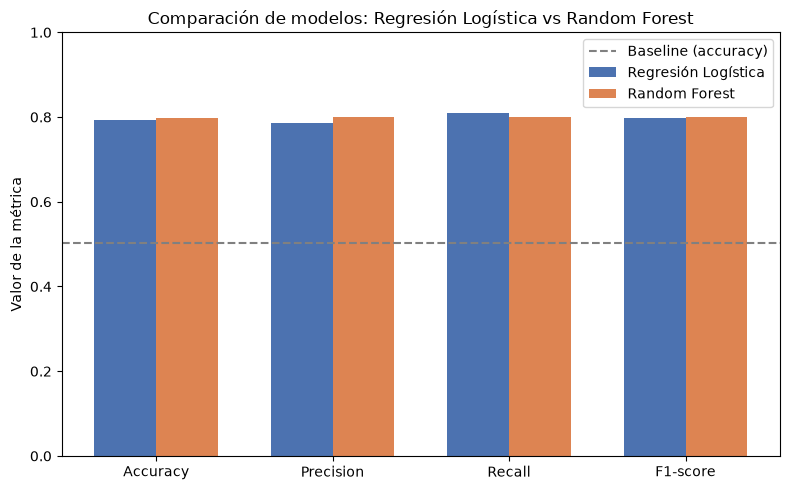

In [27]:
import matplotlib.pyplot as plt
import numpy as np

metricas = ["Accuracy", "Precision", "Recall", "F1-score"]
valores_lr = [acc_lr, prec_lr, rec_lr, f1_lr]
valores_rf = [acc_rf, prec_rf, rec_rf, f1_rf]

x = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - ancho/2, valores_lr, ancho, label="Regresión Logística", color="#4C72B0")
ax.bar(x + ancho/2, valores_rf, ancho, label="Random Forest", color="#DD8452")
ax.axhline(baseline_accuracy, color="gray", linestyle="--", label="Baseline (accuracy)")

ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Comparación de modelos: Regresión Logística vs Random Forest")
ax.legend()

plt.tight_layout()
plt.show()

La gráfica confirma visualmente lo que muestra la tabla: ambas barras están muy cerca entre sí en las cuatro métricas, muy por encima de la línea del baseline. La única barra donde Random Forest queda por debajo de Regresión Logística es en Recall, consistente con que comete más falsos negativos.

# 5. Componente Individual: Exploración de Hiperparámetros

Cada integrante trabaja de forma independiente sobre el modelo elegido en la Sección 4, modificando un hiperparámetro distinto al de sus
compañeros.

## Emilio Páez de la Mora A01801224

**Hiperparámetro elegido:** `min_samples_leaf`

En la Sección 3, Random Forest se entrenó con `min_samples_leaf=1` (valor por defecto de sklearn), lo que permite que un árbol cree una hoja para representar un solo pasajero del conjunto de entrenamiento. Esto puede llevar a hojas demasiado específicas que memorizan casos particulares en vez de patrones generales (overfitting).

Cambio `min_samples_leaf` de 1 a **5**: obligo a que cada hoja represente al menos 5 pasajeros. **Lo que espero que pase:** que el modelo generalice mejor (menos overfitting), posiblemente a costa de una ligera caída en accuracy sobre el propio conjunto de entrenamiento, pero con mejor estabilidad en el conjunto de validación.

In [28]:
modelo_rf_emilio = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)
modelo_rf_emilio.fit(X_train, y_train)
y_pred_rf_emilio = modelo_rf_emilio.predict(X_test)

acc_rf_emilio = accuracy_score(y_test, y_pred_rf_emilio)
prec_rf_emilio = precision_score(y_test, y_pred_rf_emilio)
rec_rf_emilio = recall_score(y_test, y_pred_rf_emilio)
f1_rf_emilio = f1_score(y_test, y_pred_rf_emilio)
cm_rf_emilio = confusion_matrix(y_test, y_pred_rf_emilio)

print(f"Accuracy : {acc_rf_emilio:.4f}")
print(f"Precision: {prec_rf_emilio:.4f}")
print(f"Recall   : {rec_rf_emilio:.4f}")
print(f"F1-score : {f1_rf_emilio:.4f}")
print("Matriz de confusion:\n", cm_rf_emilio)

Accuracy : 0.7976
Precision: 0.7957
Recall   : 0.8048
F1-score : 0.8002
Matriz de confusion:
 [[682 181]
 [171 705]]


In [29]:
comparacion_emilio = pd.DataFrame({
    "Versión": ["Random Forest (Sección 4)", "Random Forest (min_samples_leaf=5)"],
    "Accuracy": [acc_rf, acc_rf_emilio],
    "Precision": [prec_rf, prec_rf_emilio],
    "Recall": [rec_rf, rec_rf_emilio],
    "F1-score": [f1_rf, f1_rf_emilio],
})
comparacion_emilio

,Versión,Accuracy,Precision,Recall,F1-score
0,Random Forest (Sección 4),0.798735,0.800915,0.799087,0.800000
1,Random Forest (min_samples_leaf=5),0.797585,0.795711,0.804795,0.800227


Al subir `min_samples_leaf` de 1 a 5, no hubo una mejora o un empeoramiento conctreo, ya que:

- **Accuracy**: bajó ligermanete de 0.7987 -> 0.7975 diff = -0.0012
- **Precision:** bajó más en comparación a las demás méricas 0.8009 -> 0.7957 diff = -0.0052
- **Recall:** subió  de 0.7990 → 0.8047 diff = +0.0057
- **F1-score**: práctivamente no tuvo ningún cambio 0.8000 → 0.8002 diff = +0.0002

En parte tiene sentido con lo que esperaba, pero no como lo había pensado, forzar hojas más grandes hizo que el modelo dejara de ajustarse a casos muy espec´´ificos del entrenamiento y se volvio "generoso" al prwedecir la clase transportado - capturó mas verdaderospositivos (mejor recall), pero a cambio también genrró más falsos positivos (peor precision). 

No fue una reducciónm general de error como creí, sino un cambio en el **tipo de error** que comete el modelo: pasó de ser preciso a uno más sensible

El F1-score casi no se movio porque ambos efectos a recall y precission se hicieron que practicamente se cancelara. Lo que sugiere que dataset y estos rangos de `min_samples_leaf`, el modelo ya estaba cerca de un punto de equilibrio entre sesgo y varianza: forzar árboles más simples no lo mejora de forma clara, solo reacomoda dónde comete sus errores.

In [30]:
# Extra: mover C en Regresión Logística
modelo_lr_emilio = LogisticRegression(max_iter=1000, C=0.1, random_state=RANDOM_STATE)
modelo_lr_emilio.fit(X_train, y_train)
y_pred_lr_emilio = modelo_lr_emilio.predict(X_test)

acc_lr_emilio = accuracy_score(y_test, y_pred_lr_emilio)
prec_lr_emilio = precision_score(y_test, y_pred_lr_emilio)
rec_lr_emilio = recall_score(y_test, y_pred_lr_emilio)
f1_lr_emilio = f1_score(y_test, y_pred_lr_emilio)

comparacion_lr_extra = pd.DataFrame({
    "Versión": ["Regresión Logística (Sección 3, C=1.0)", "Regresión Logística (C=0.1)"],
    "Accuracy": [acc_lr, acc_lr_emilio],
    "Precision": [prec_lr, prec_lr_emilio],
    "Recall": [rec_lr, rec_lr_emilio],
    "F1-score": [f1_lr, f1_lr_emilio],
})
comparacion_lr_extra

,Versión,Accuracy,Precision,Recall,F1-score
0,"Regresión Logística (Sección 3, C=1.0)",0.793560,0.786903,0.809361,0.797974
1,Regresión Logística (C=0.1),0.790684,0.784444,0.805936,0.795045


Bajar `C` de 1.0 a 0.1 empeoró las cuatro métricas ligeramente (accuracy
−0.0029, precision −0.0025, recall −0.0034, F1 −0.0029). A diferencia de
Random Forest, aquí no hubo un trade-off entre precision y recall: ambas
bajaron juntas, así que el modelo simplemente perdió capacidad predictiva
sin ganar nada a cambio. Esto sugiere que la Regresión Logística ya estaba
bien regularizada en su configuración original.

## Alejandro Vázquez de la Cruz A01800791

**Hiperparámetro elegido:** `max_depth`

Se aumentará la profundidad del árbol buscando mejorar el modelo. Al aumentar max_depth se busca que el modelo sea más complejo y logre capturar más patrones, sin embargo existe el riesgo de que sean demasiados y que termine emperoando el modelo.

Para el siguiente ejercicio se escogio arbitrariamente una profundidad máxima de 15.

In [31]:
modelo_rf_alex = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
)
modelo_rf_alex.fit(X_train, y_train)
y_pred_rf_alex = modelo_rf_alex.predict(X_test)

acc_rf_alex = accuracy_score(y_test, y_pred_rf_alex)
prec_rf_alex = precision_score(y_test, y_pred_rf_alex)
rec_rf_alex = recall_score(y_test, y_pred_rf_alex)
f1_rf_alex = f1_score(y_test, y_pred_rf_alex)
cm_rf_alex = confusion_matrix(y_test, y_pred_rf_alex)

print(f"Accuracy : {acc_rf_alex:.4f}")
print(f"Precision: {prec_rf_alex:.4f}")
print(f"Recall   : {rec_rf_alex:.4f}")
print(f"F1-score : {f1_rf_alex:.4f}")
print("Matriz de confusion:\n", cm_rf_alex)

Accuracy : 0.8010
Precision: 0.8155
Recall   : 0.7820
F1-score : 0.7984
Matriz de confusion:
 [[708 155]
 [191 685]]


In [33]:
comparacion_alex = pd.DataFrame({
    "Versión": ["Random Forest (Sección 4)", "Random Forest (max_depht=15)"],
    "Accuracy": [acc_rf, acc_rf_alex],
    "Precision": [prec_rf, prec_rf_alex],
    "Recall": [rec_rf, rec_rf_alex],
    "F1-score": [f1_rf, f1_rf_alex],
})
comparacion_alex

,Versión,Accuracy,Precision,Recall,F1-score
0,Random Forest (Sección 4),0.798735,0.800915,0.799087,0.800000
1,Random Forest (max_depht=15),0.801035,0.815476,0.781963,0.798368


Al aumentar max_depth de 10 a 15, los árboles tienen mayor capacidad para realizar divisiones y encontrar patrones más específicos y complejos en los datos. Esto explica principalmente el aumento en la precision, ya que el modelo logra ser más preciso cuando predice una determinada clase.

Sin embargo, esta mayor complejidad también puede hacer que el modelo se adapte demasiado a ciertos patrones específicos de los datos de entrenamiento. Esto puede provocar que, aunque aumente ligeramente la cantidad de predicciones correctas en general (accuracy), el modelo tenga más dificultades para identificar algunos casos positivos, lo que se refleja en la disminución del recall.

En este caso, aumentar la profundidad no produjo una mejora general del modelo: aunque el accuracy y precision aumentaron, el recall disminuyó y el F1-score también tuvo una pequeña reducción. Por ello, max_depth=10 parece ofrecer un mejor equilibrio entre precision y recall, mientras que max_depth=15 hace al modelo ligeramente más preciso, pero a costa de detectar menos casos positivos.

## Integrante 3

## Integrante 4

## Integrante 5

# 6. Verificación y Cierre
